# ラボ 3.7 - 学生用ノートブック

## 概要

実習3_7です。与えられたデータを基に学習を深めてみましょう。

このラボでは、ハイパーパラメータの調整ジョブを作成し、前に作成したモデルをチューニングします。続いて、2 つのモデルのメトリクスを比較します。


## 業務シナリオの紹介

あなたはある医療機関に勤務しており、乳癌（にゅうがん、英: Breast cancer）の検出を改善したいと考えています。

機械学習 (ML) を利用してこの問題を解決するのがあなたの課題です。このデータセットを使用して ML モデルのトレーニングを行い、患者に異常があるかどうかを予測します。

## このデータセットについて

breast_cancer.csv　は、Pythonのscikit-learn付属データセットに用意されており、ダウンロードしたデータです。

## 属性情報

PowerPointをご覧ください。
このデータセットの詳細については、 (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) を参照してください。

## データのインポート

以下の3つのセルは、前回の3-6のコードをまとめたものです。
実行するとデータがインポートされ、使用できる状態になります。

**注:** 次のセルは、以前のラボでの重要なステップです。消さないように注意
**fit** を実行するとモデルがトレーニングされます。
**注:** この処理は最長15分かかることがあります。



In [1]:
# S3のバケット名を指定するための変数を作成（ご自身のパケットに変更）
bucket=''

In [2]:
# 時間計測のためのライブラリをインポート
import time

# 開始時刻を記録
start = time.time()

# 警告メッセージを無視するためにwarningsモジュールを使用
import warnings, requests, zipfile, io

# 警告メッセージを無視するフィルターを設定
warnings.simplefilter('ignore')

# データ処理のためにpandasモジュールをインポート
import pandas as pd

# 科学技術計算のためにscipyモジュールからarffファイルの入出力関数をインポート
from scipy.io import arff

# ローカルのオペレーティングシステムにアクセスするためにosモジュールをインポート
import os

# AWSのSageMakerサービスを使用するためにboto3とsagemakerモジュールをインポート
import boto3
import sagemaker

# SageMakerにおけるデフォルトのコンテナイメージを取得するためにretrieveメソッドを使用
from sagemaker.image_uris import retrieve

# データをトレーニングセットとテストセットに分割するためにtrain_test_splitメソッドを使用
from sklearn.model_selection import train_test_split

# 機械学習モデルの性能評価のための指標や図を生成するためのライブラリをインポート
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [3]:
%%time
# numpyライブラリを np としてインポート
import numpy as np

def plot_roc(test_labels, target_predicted_binary):
    # 混同行列を計算
    TN, FP, FN, TP = confusion_matrix(test_labels, target_predicted_binary).ravel()
    # Sensitivity（感度）: 真陽性率を計算しています。実際に陽性のケースのうち、正しく陽性と判定された割合です。
    Sensitivity = float(TP) / (TP + FN) * 100
    # Specificity（特異度）: 真陰性率を計算しています。実際に陰性のケースのうち、正しく陰性と判定された割合です。
    Specificity = float(TN) / (TN + FP) * 100
    #Precision（適合率）: 真陽性率を計算しています。陽性と判定されたケースのうち、実際に陽性である割合です。
    Precision = float(TP) / (TP + FP) * 100
    # NPV（陰性的中率）: 真陰性率を計算しています。陰性と判定されたケースのうち、実際に陰性である割合です。
    NPV = float(TN) / (TN + FN) * 100
    # FPR（偽陽性率）: 偽陽性率を計算しています。実際に陰性のケースのうち、誤って陽性と判定された割合です。
    FPR = float(FP) / (FP + TN) * 100
    # FNR（偽陰性率）: 偽陰性率を計算しています。実際に陽性のケースのうち、誤って陰性と判定された割合です。
    FNR = float(FN) / (TP + FN) * 100
    # FDR（誤発見率）: 誤って陽性と判定されたケースのうち、実際に陰性である割合です。
    FDR = float(FP) / (TP + FP) * 100
    # ACC（正解率）: 全体のケースのうち、正しく分類された割合です。
    ACC = float(TP + TN) / (TP + FP + FN + TN) * 100

    # 評価指標の出力
    print(f"Sensitivity or TPR: {Sensitivity}%")    
    print(f"Specificity or TNR: {Specificity}%") 
    print(f"Precision: {Precision}%")   
    print(f"Negative Predictive Value: {NPV}%")  
    print( f"False Positive Rate: {FPR}%") 
    print(f"False Negative Rate: {FNR}%")  
    print(f"False Discovery Rate: {FDR}%" )
    print(f"Accuracy: {ACC}%") 

    # テストデータのラベル取得
    test_labels = test.iloc[:,0];
    print("Validation AUC", roc_auc_score(test_labels, target_predicted_binary) )

    # ROC曲線の作成
    fpr, tpr, thresholds = roc_curve(test_labels, target_predicted_binary)
    roc_auc = auc(fpr, tpr)

    # ROC曲線のプロット
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % (roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")

    # 閾値の軸の作成
    ax2 = plt.gca().twinx()
    ax2.plot(fpr, thresholds, markeredgecolor='r',linestyle='dashed', color='r')
    ax2.set_ylabel('Threshold',color='r')
    thresholds = [value for value in thresholds if np.isfinite(value)]
    ax2.set_ylim([min(thresholds), max(thresholds)])
    ax2.set_xlim([fpr[0],fpr[-1]])

    # プロットの表示
    print(plt.figure())

# 混同行列をプロットするための関数を定義
def plot_confusion_matrix(test_labels, target_predicted):
    # 混同行列を計算
    matrix = confusion_matrix(test_labels, target_predicted)
    
    # 混同行列をDataFrameに変換
    df_confusion = pd.DataFrame(matrix)
    
    # カラーマップを指定
    colormap = sns.color_palette("BrBG", 10)
    
    # Seabornのヒートマップを使用して混同行列をプロット
    sns.heatmap(df_confusion, annot=True, fmt='.2f', cbar=None, cmap=colormap)
    
    # グラフにタイトルを追加
    plt.title("Confusion Matrix")
    
    # グラフのレイアウトを整える
    plt.tight_layout()
    
    # y軸ラベルを設定
    plt.ylabel("True Class")
    
    # x軸ラベルを設定
    plt.xlabel("Predicted Class")
    
    # グラフを表示
    plt.show()

# pandasライブラリを使って、AWS S3上のCSVファイルを読み込む
# 事前に必要なデータをS3にアップロードをして、URIをメモしておいてください。
df = pd.read_csv('')

# DataFrameの列名をリストに変換
cols = df.columns.tolist()

# 先頭の列を末尾に移動するためにスライスを使用
cols = cols[-1:] + cols[:-1]

# 列の順序を変更するためにDataFrameを再構築
df = df[cols]

# データセットをトレーニングセットとテスト＆検証セットに分割するためにtrain_test_split関数を使用
# test_sizeでテスト＆検証セットの割合を指定し、random_stateで乱数のシードを固定
# stratifyでクラスの分布を保持して分割
train, test_and_validate = train_test_split(df, test_size=0.2, random_state=42, stratify=df['target'])

# train_test_split関数を使用してデータを分割
# test_and_validateデータをtestとvalidateに分割し、test_sizeで分割比率を指定
# random_stateで再現性を確保し、stratifyで層別サンプリングを行う（'class'列を考慮）
test, validate = train_test_split(test_and_validate, test_size=0.5, random_state=42, stratify=test_and_validate['target'])

# S3バケットとプレフィックスの設定
prefix='lab3'

# 訓練データ、テストデータ、検証データのファイル名設定
train_file='vertebral_train.csv'
test_file='vertebral_test.csv'
validate_file='vertebral_validate.csv'

# S3リソースを取得
s3_resource = boto3.Session().resource('s3')

# S3にCSVファイルをアップロードするための関数を定義
def upload_s3_csv(filename, folder, dataframe):
    csv_buffer = io.StringIO()
    dataframe.to_csv(csv_buffer, header=False, index=False)
    s3_resource.Bucket(bucket).Object(os.path.join(prefix, folder, filename)).put(Body=csv_buffer.getvalue())
    
# train_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(train_file, 'train', train)

# test_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(test_file, 'test', test)

# validate_fileというCSVファイルをS3にアップロードするためにupload_s3_csv関数を使用
upload_s3_csv(validate_file, 'validate', validate)

# SageMakerにおいてXGBoostアルゴリズムを利用するためのコンテナイメージを取得
container = retrieve('xgboost',boto3.Session().region_name,'1.0-1')

# XGBoostのハイパーパラメータを設定するための辞書を作成
hyperparams={"num_round":"42",
             "eval_metric": "auc",
             "objective": "binary:logistic",
             "silent": 1}

# 出力先のS3ロケーションを設定
s3_output_location="s3://{}/{}/output/".format(bucket,prefix)

# SageMakerのXGBoostアルゴリズムを使用するためにXGBoost Estimatorを作成
# container: 使用するコンテナの指定
# sagemaker.get_execution_role(): SageMakerの実行ロールを取得
# instance_count: モデルトレーニングに使用するインスタンスの数を指定
# instance_type: モデルトレーニングに使用するインスタンスのタイプを指定
# output_path: トレーニングアーティファクト（モデルアーティファクト）のS3出力先を指定
# hyperparameters: XGBoostのハイパーパラメータを指定
# sagemaker_session: SageMakerセッションを指定
xgb_model=sagemaker.estimator.Estimator(container,
                                       sagemaker.get_execution_role(),
                                       instance_count=1,
                                       instance_type='ml.m4.xlarge',
                                       output_path=s3_output_location,
                                        hyperparameters=hyperparams,
                                        sagemaker_session=sagemaker.Session())

# SageMakerのトレーニングジョブに使用するトレーニングデータのS3パスとコンテントタイプを指定
train_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/train/".format(bucket,prefix,train_file),
    content_type='text/csv')

# SageMakerのトレーニングジョブに使用する検証データのS3パスとコンテントタイプを指定
validate_channel = sagemaker.inputs.TrainingInput(
    "s3://{}/{}/validate/".format(bucket,prefix,validate_file),
    content_type='text/csv')

# トレーニングジョブのデータチャネルにトレーニングデータと検証データを指定
data_channels = {'train': train_channel, 'validation': validate_channel}

# XGBoostモデルを学習させるためにfitメソッドを使用
# inputsにはデータチャネルを指定し、logsをFalseに設定してログを表示しないようにする
xgb_model.fit(inputs=data_channels, logs=False)

# ホスティングの準備が完了したことを表示
print('ready for hosting!')

# テストデータから特徴量を抽出し、1列目以降を取得
batch_X = test.iloc[:,1:];

# バッチデータの入力ファイル名を指定
batch_X_file='batch-in.csv'

# バッチデータをS3にアップロード
upload_s3_csv(batch_X_file, 'batch-in', batch_X)

# バッチ変換の出力先を指定
batch_output = "s3://{}/{}/batch-out/".format(bucket,prefix)

# バッチ変換の入力データのパスを指定
batch_input = "s3://{}/{}/batch-in/{}".format(bucket,prefix,batch_X_file)

# XGBoostトランスフォーマーを作成
# instance_count: トランスフォーマーの実行に使用するインスタンスの数
# instance_type: トランスフォーマーのインスタンスのタイプ
# strategy: バッチ変換のストラテジーを指定（MultiRecordは複数の入力レコードに対応）
# assemble_with: バッチ変換の際に結果をどのようにまとめるか指定（Lineは行ごとにまとめる）
# output_path: バッチ変換の結果を保存するS3のパスを指定
xgb_transformer = xgb_model.transformer(instance_count=1,
                                       instance_type='ml.m4.xlarge',
                                       strategy='MultiRecord',
                                       assemble_with='Line',
                                       output_path=batch_output)

# バッチ変換を実行
# data: 変換対象のデータのパスを指定
# data_type: 変換対象のデータのタイプを指定（S3PrefixはS3上のプレフィックス内のデータを指定）
# content_type: 変換対象データのコンテンツタイプを指定
# split_type: 入力データをどのように分割するか指定（Lineは行ごとに分割）
xgb_transformer.transform(data=batch_input,
                         data_type='S3Prefix',
                         content_type='text/csv',
                         split_type='Line')

# バッチ変換が完了するのを待機
xgb_transformer.wait()

# バッチ変換完了が完了したことを表示
print('Batch transformation completed!')

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2024-01-07-03-20-38-688



2024-01-07 03:20:39 Starting - Starting the training job...
2024-01-07 03:21:02 Starting - Preparing the instances for training................
2024-01-07 03:22:27 Downloading - Downloading input data.....
2024-01-07 03:22:57 Downloading - Downloading the training image.........
2024-01-07 03:23:48 Training - Training image download completed. Training in progress...
2024-01-07 03:24:03 Uploading - Uploading generated training model..
2024-01-07 03:24:19 Completed - Training job completed

INFO:sagemaker:Creating model with name: sagemaker-xgboost-2024-01-07-03-24-21-052



ready for hosting!


INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2024-01-07-03-24-21-703


...................................[2024-01-07:03:30:09:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:30:09:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:30:09:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
[2024-01-07:03:30:09:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:30:09:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:03:30:09:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocati

# ステップ 1: モデル統計の取得

モデルを調整する前に、現在のモデルのメトリクスを再確認してください。

セットアップでバッチ予測を実行したので、Amazon Simple Storage Service (Amazon S3) から結果を読み込む必要があります。

In [5]:
# boto3モジュールを使用してS3クライアントを作成
s3 = boto3.client('s3')

# S3バケットからオブジェクトを取得
obj = s3.get_object(Bucket=bucket, Key="{}/batch-out/{}".format(prefix,'batch-in.csv.out'))

# バッチ変換の結果として得られた予測結果を読み込む
# ここではCSVデータを読み込み、列名を指定してDataFrameに変換
target_predicted = pd.read_csv(io.BytesIO(obj['Body'].read()),sep=',',names=['target'])

# 閾値を設定して二値変換する関数を定義
# binary_convert関数では、確率が指定された閾値（ここでは0.65）より大きい場合は1、それ以外は0に変換されます。
def binary_convert(x):
    threshold = 0.65
    if x > threshold:
        return 1
    else:
        return 0

# 'target'列の各要素に二値変換を適用し、新しい 'binary' 列を作成
target_predicted_binary = target_predicted['target'].apply(binary_convert)

# テストデータのクラスラベル列を抽出する
test_labels = test.iloc[:,0]


元のモデルの混同行列と受信者操作特性 (ROC) 曲線をプロットします。


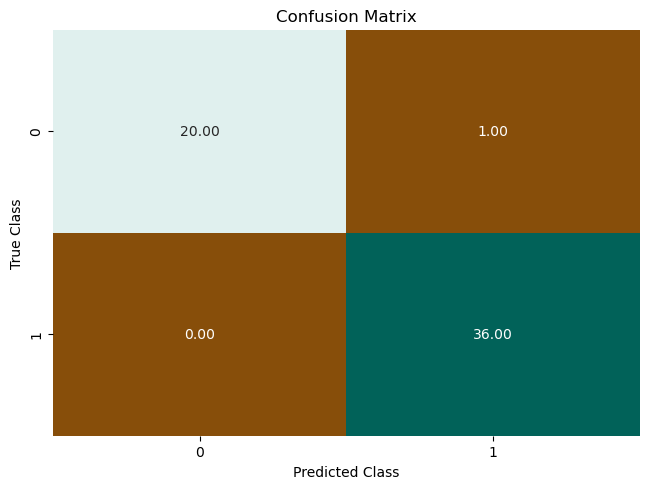

In [6]:
# 混同行列を可視化するための関数を呼び出し
# 混同行列は、分類モデルの性能を評価するために使用され、実際のクラスとモデルが予測したクラスとの間の対応関係を示します。
plot_confusion_matrix(test_labels, target_predicted_binary)

Sensitivity or TPR: 100.0%
Specificity or TNR: 95.23809523809523%
Precision: 97.2972972972973%
Negative Predictive Value: 100.0%
False Positive Rate: 4.761904761904762%
False Negative Rate: 0.0%
False Discovery Rate: 2.7027027027027026%
Accuracy: 98.24561403508771%
Validation AUC 0.9761904761904762
Figure(640x480)


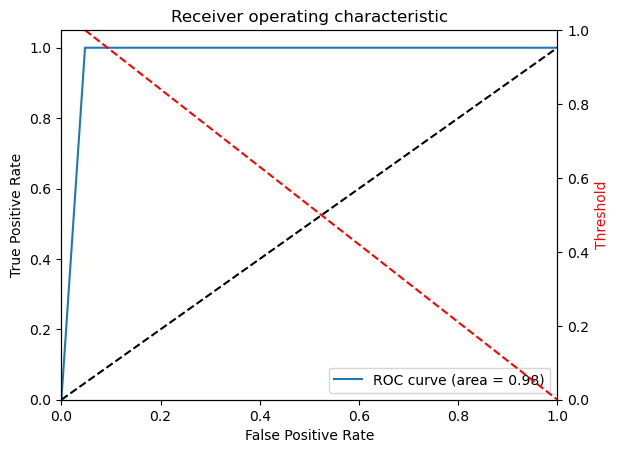

<Figure size 640x480 with 0 Axes>

In [7]:
# ROC曲線をプロットするための関数を呼び出し
plot_roc(test_labels, target_predicted_binary)

このプロットが開始点になります。*検証曲線下面積 (AUC)* を覚えておいてください。あとでそれを使ってチューニング後のモデルをチェックし、改善されているかどうかを確認します。

# ステップ 2: ハイパーパラメータの調整ジョブの作成

ハイパーパラメータの調整ジョブは、指定した値の範囲によっては、完了まで数時間かかることがあります。タスクを簡略化するため、このステップで使用するパラメータは、推奨範囲のサブセットです。完了までに数時間かけなくても、このラボで良好な結果が得られるように調整されています。

XGBoost 用に調整するパラメータの詳細については、AWS ドキュメントの [チューニング XGBoost モデル] (https://docs.aws.amazon.com/sagemaker/latest/dg/xgboost-tuning.html) を参照してください。

この次のセルは終了までに時間がかかる可能性があるため、先にセルを実行します。何が起こっているのか、そしてこれらのハイパーパラメータ範囲がなぜ選択されたかを詳しく見ます。

In [8]:
%%time
# SageMakerのハイパーパラメータ調整用のライブラリをインポート
from sagemaker.tuner import IntegerParameter, CategoricalParameter, ContinuousParameter, HyperparameterTuner

# XGBoost Estimatorの設定
xgb = 





# XGBoostのハイパーパラメータの設定
xgb.set_hyperparameters()

# ハイパーパラメータの探索範囲を指定
hyperparameter_ranges = {}

# ハイパーパラメータの調整のための目的のメトリクスの名前を設定します。ここでは検証データのエラーを最小化するようにします。
objective_metric_name = 

# 目的関数の種類を指定します。ここでは最小化が目標です。
objective_type = 

# ハイパーパラメータのチューニングを行うためのHyperparameterTunerオブジェクトを作成します。
tuner = HyperparameterTuner()

# ハイパーパラメータのチューニングを実行します。データチャネルとクラスメタデータは含めません。
tuner.fit()

# チューニングが完了するのを待ちます。
tuner.wait()

# チューニングが完了したことを表示
print('Tuning completed!')

INFO:sagemaker:Creating hyperparameter tuning job with name: sagemaker-xgboost-240107-0401


.................................................................................................................................................................................!
!
Tuning completed!
CPU times: user 1.02 s, sys: 58.2 ms, total: 1.08 s
Wall time: 15min 14s


まず、調整するモデルを作成します。

```
xgb = sagemaker.estimator.Estimator(container,
                                   role=sagemaker.get_execution_role(), 
                                   instance_count= 1, # make sure you have limit set for these instances
                                   instance_type='ml.m4.xlarge', 
                                   output_path='s3://{}/{}/output'.format(bucket, prefix),
                                   sagemaker_session=sagemaker.Session())

xgb.set_hyperparameters(eval_metric='[error@.40]',
                        objective='binary:logistic',
                        num_round=42)

```                        

モデルの *eval_metric* が *error@.40* に変更され、その値を最小化するのが目的であることに注意してください。

**error** はバイナリー分類のエラー率です。これは *#(wrong cases)/#(all cases)* として計算されます。予測のために、評価では 0.4 より大きい予測値を持つインスタンスは陽性のインスタンス、その他は陰性のインスタンスとみなされます。

次に、チューニングするハイパーパラメータ、加えて各パラメータについて選択が必要な範囲を指定する必要があります。

XGBoost の目標メトリクスに最も影響を与えるハイパーパラメータを以下に示します。 

- alpha
- min_child_weight
- subsample
- eta
- num_round 

推奨されるチューニング範囲は、AWS ドキュメントの [チューニング XGBoost モデル] (https://docs.aws.amazon.com/sagemaker/latest/dg/xgboost-tuning.html) を参照してください。

このラボでは、値の *サブセット* を使用します。これらの値は、調整ジョブを全範囲で実行してから範囲を最小化して取得されているため、反復を減らしてパフォーマンスを上げることができます。厳密にはこの方法は現実に即していませんが、このラボでチューニングジョブの完了を数時間待つことが避けられます。

```
hyperparameter_ranges = {'alpha': ContinuousParameter(0, 100),
                         'min_child_weight': ContinuousParameter(1, 5),
                         'subsample': ContinuousParameter(0.5, 1),
                         'eta': ContinuousParameter(0.1, 0.3),  
                         'num_round': IntegerParameter(1,50)
                         }
```


モデルの評価方法を指定する必要があります。複数の異なる目標メトリクスを使用でき、そのサブセットがバイナリー分類の問題に適用されます。評価メトリクスは **エラー** なので、目標を *エラー* に設定します。

```
objective_metric_name = 'validation:error'
objective_type = 'Minimize'
```

最後に、調整ジョブを実行します。

```
tuner = HyperparameterTuner(xgb,
                            objective_metric_name,
                            hyperparameter_ranges,
                            max_jobs=10, # Set this to 10 or above depending upon budget & available time.
                            max_parallel_jobs=1,
                            objective_type=objective_type,
                            early_stopping_type='Auto')

tuner.fit(inputs=data_channels, include_cls_metadata=False)
tuner.wait()
```



<i class="fas fa-exclamation-triangle" style="color:red"></i> トレーニングジョブが終了するまで待ちます。15～25 分かかる場合があります。待っている間に、次の手順に従って、コンソールでジョブのステータスを確認します。

**ハイパーパラメータの最適化ジョブを監視するには:**  

1. AWS マネジメントコンソールの **サービス** メニューで **Amazon SageMaker** をクリックします。 
2. [**トレーニング**] > [**ハイパーパラメータの調整ジョブ**] の順にクリックします。 
3. ハイパーパラメータの調整ジョブそれぞれのステータス、そのジョブの目標メトリクス値、ログを確認できます。 

トレーニングジョブが終了したら、ジョブをチェックし、正常に完了したかを確認します。

In [9]:
# boto3ライブラリを使用してSageMakerクライアントを作成
# client = boto3.client('sagemaker')
# 最新のチューニングジョブのジョブ名を取得
# latest_tuning_job_name = tuner.latest_tuning_job.job_name
# ハイパーパラメーターチューニングジョブのステータスを取得
# tuning_job_status = client.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=latest_tuning_job_name)['HyperParameterTuningJobStatus']


'Completed'

# ステップ 3: 調整ジョブの結果の調査

すべてのジョブが終了した時点で、完了したジョブは 10 個あるはずです。いずれかのジョブが最良としてマークされています。

*HyperparameterTuningJobAnalytics* を取得し、そのデータを pandas DataFrame にロードすることにより、メトリクスを調べることができます。


In [10]:
# pprintモジュールからpprint関数をインポート
from pprint import pprint

# sagemaker.analyticsモジュールからHyperparameterTuningJobAnalyticsクラスをインポート
from sagemaker.analytics import HyperparameterTuningJobAnalytics

# 最新のハイパーパラメータチューニングジョブの名前を使用してHyperparameterTuningJobAnalyticsオブジェクトを作成
tuner_analytics = 

# ハイパーパラメータチューニングジョブの分析データをDataFrameとして取得
df_tuning_job_analytics = 

# ファイナルメトリクスの値でチューニングジョブの分析データをソート
df_tuning_job_analytics.sort_values()

# 上位20モデルの詳細な分析データを表示


,alpha,eta,min_child_weight,num_round,subsample,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
1,41.230654,0.153391,1.073206,4.0,0.694249,sagemaker-xgboost-240107-0401-009-5a832099,Completed,0.07018,2024-01-07 04:14:48+00:00,2024-01-07 04:15:17+00:00,29.0
4,23.586463,0.114213,1.828441,9.0,0.597245,sagemaker-xgboost-240107-0401-006-e6a05a8a,Completed,0.07018,2024-01-07 04:10:31+00:00,2024-01-07 04:12:24+00:00,113.0
7,91.266687,0.208942,1.417841,33.0,0.780412,sagemaker-xgboost-240107-0401-003-9adf6388,Completed,0.07018,2024-01-07 04:06:21+00:00,2024-01-07 04:06:53+00:00,32.0
0,97.619994,0.294106,2.514266,4.0,0.787138,sagemaker-xgboost-240107-0401-010-eed85fa3,Completed,0.08772,2024-01-07 04:15:38+00:00,2024-01-07 04:16:10+00:00,32.0
2,15.885079,0.100000,1.505463,19.0,0.848308,sagemaker-xgboost-240107-0401-008-1c9d1d24,Completed,0.08772,2024-01-07 04:13:51+00:00,2024-01-07 04:14:28+00:00,37.0
3,55.462325,0.197210,2.030052,38.0,0.954284,sagemaker-xgboost-240107-0401-007-6589e82e,Completed,0.08772,2024-01-07 04:13:00+00:00,2024-01-07 04:13:37+00:00,37.0
5,72.037220,0.186610,2.048029,25.0,0.981392,sagemaker-xgboost-240107-0401-005-00a22e4b,Stopped,0.08772,2024-01-07 04:07:49+00:00,2024-01-07 04:08:18+00:00,29.0
6,87.911363,0.295910,4.513287,31.0,0.978376,sagemaker-xgboost-240107-0401-004-7bde0019,Completed,0.08772,2024-01-07 04:07:05+00:00,2024-01-07 04:07:36+00:00,31.0
9,32.078965,0.152844,2.546583,37.0,0.926689,sagemaker-xgboost-240107-0401-001-c514bed6,Completed,0.08772,2024-01-07 04:03:24+00:00,2024-01-07 04:05:16+00:00,112.0
8,67.694762,0.291463,2.414684,38.0,0.557530,sagemaker-xgboost-240107-0401-002-5185dc2b,Stopped,0.10526,2024-01-07 04:05:44+00:00,2024-01-07 04:06:14+00:00,30.0


各ジョブに使用されたハイパーパラメータを、そのスコアと共に確認できるはずです。これらのパラメータを使用してモデルを作成する、あるいは、ハイパーパラメータの調整ジョブから最適なモデルを取得することが可能です。

In [11]:
# HyperparameterTunerに最新の調整ジョブをアタッチします。
attached_tuner = 

# アタッチされた調整ジョブから最良のトレーニングジョブを取得します。
best_training_job = 

ここで、最適なトレーニングジョブにアタッチし、モデルを作成する必要があります。

In [12]:
# SageMakerのEstimatorクラスをimportします。
from sagemaker.estimator import Estimator

# 最良のトレーニングジョブを取得して、それに紐づくEstimatorオブジェクトを取得します。
algo_estimator = 

# Estimatorオブジェクトを使用して、SageMakerモデルを作成します。
# この際、環境変数としてSAGEMAKER_DEFAULT_INVOCATIONS_ACCEPTを指定しています。
# これにより、モデルが推論リクエストをtext/csv形式で受け入れるようになります。
best_algo_model = 


2024-01-07 04:15:19 Starting - Found matching resource for reuse
2024-01-07 04:15:19 Downloading - Downloading the training image
2024-01-07 04:15:19 Training - Training image download completed. Training in progress.
2024-01-07 04:15:19 Uploading - Uploading generated training model
2024-01-07 04:15:19 Completed - Resource released due to keep alive period expiry


次に、変換メソッドを使用して、テストデータ使用によるバッチ予測を実行します。テストデータは、モデルが以前に認識したことがないデータであることに留意してください。

In [13]:
%%time
# S3 バケットとプレフィックスを使用してバッチ出力の保存先パスを作成します
batch_output = 

# バッチ入力データの S3 パスを作成します
batch_input = 

# XGBoost モデル用の Transformer オブジェクトを作成します
xgb_transformer = best_algo_model.transformer()

# XGBoost（Extreme Gradient Boosting）トランスフォーマーを使用して、バッチ入力データを変換します。
xgb_transformer.transform()

# トランスフォーマーの完了を待機し、ログを表示しないようにします。
xgb_transformer.wait(logs=False)


INFO:sagemaker:Creating model with name: sagemaker-xgboost-2024-01-07-04-50-42-660
INFO:sagemaker:Creating transform job with name: sagemaker-xgboost-2024-01-07-04-50-43-222


....................................
[2024-01-07:04:56:45:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:04:56:45:INFO] No GPUs detected (normal if no gpus installed)
[2024-01-07:04:56:45:INFO] nginx config: 
worker_processes auto;
daemon off;
pid /tmp/nginx.pid;
error_log  /dev/stderr;
worker_rlimit_nofile 4096;
events {
  worker_connections 2048;
}
http {
  include /etc/nginx/mime.types;
  default_type application/octet-stream;
  access_log /dev/stdout combined;
  upstream gunicorn {
    server unix:/tmp/gunicorn.sock;
  }
  server {
    listen 8080 deferred;
    client_max_body_size 0;
    keepalive_timeout 3;
    location ~ ^/(ping|invocations|execution-parameters) {
      proxy_set_header X-Forwarded-For $proxy_add_x_forwarded_for;
      proxy_set_header Host $http_host;
      proxy_redirect off;
      proxy_read_timeout 60s;
      proxy_pass http://gunicorn;
    }
    location / {
      return 404 "{}";
    }
  }
}
[2024-01-07 04:56:45 +0000] [19] [INFO] Startin

モデルの予測ターゲットとテストラベルを取得します。

In [19]:
# boto3ライブラリを使用してS3クライアントを作成
s3 = 

# S3から特定のオブジェクトを取得するための情報を指定してオブジェクトを取得
obj = 

# 取得したCSVデータをPandasのデータフレームとして読み込み
best_target_predicted = 

# 二値変換関数を定義します。
def binary_convert(x):
    threshold = 0.5
    # 与えられた値が閾値より大きい場合、1を返します。
    if x > threshold:
        return 1
    # それ以外の場合は、0を返します。
    else:
        return 0

# DataFrame列 'target' に二値変換関数を適用して、新しい列を作成します。
best_target_predicted_binary = 

# 'test' DataFrame の最初の列をテストラベルとして取得します。
test_labels = 


`best_target_predicted` と `test_labels` の混同行列をプロットします。

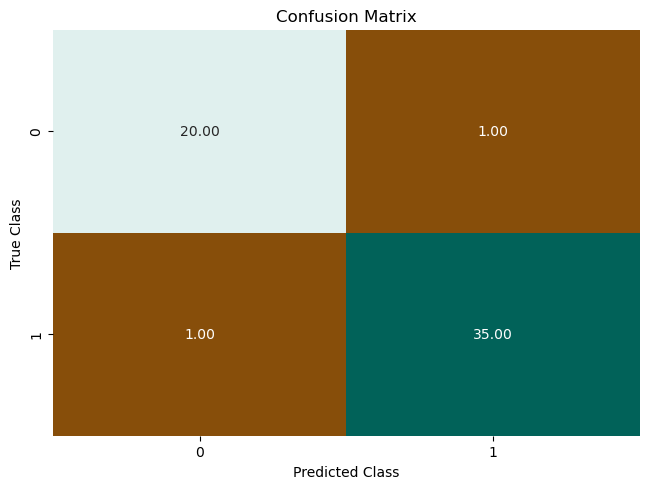

In [20]:
plot_confusion_matrix(test_labels, best_target_predicted_binary)

ROC のグラフをプロットします。

Sensitivity or TPR: 97.22222222222221%
Specificity or TNR: 95.23809523809523%
Precision: 97.22222222222221%
Negative Predictive Value: 95.23809523809523%
False Positive Rate: 4.761904761904762%
False Negative Rate: 2.7777777777777777%
False Discovery Rate: 2.7777777777777777%
Accuracy: 96.49122807017544%
Validation AUC 0.9623015873015873
Figure(640x480)


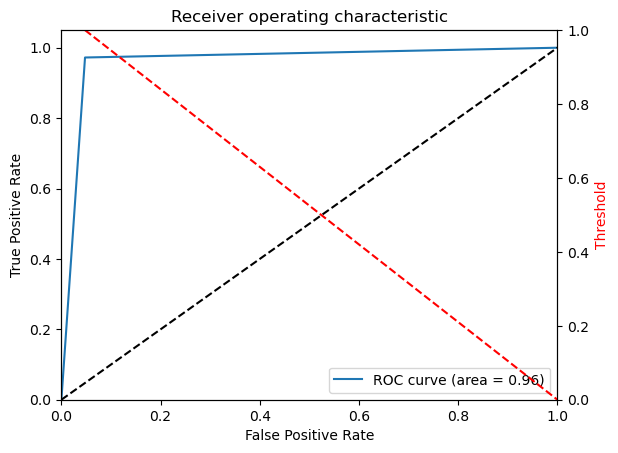

<Figure size 640x480 with 0 Axes>

In [21]:
# ROC曲線の描画に必要な関数を呼び出す


**質問:** 元の結果と比べてどのような違いがありますか? 結果は良くなっていますか、それとも悪くなっていますか? 

必ずしも改善されているとは限りません。この結果にはいくつか理由があります。

- モデルが最初のテストを通過した時点ですでに良好だった可能性がある (何を *良好* とするかは主観によります)。
- トレーニングするデータの量が多くない。
- このラボでは時間短縮のためにハイパーパラメータのチューニング範囲の *サブセット* を使用している。

ハイパーパラメータの範囲を広げ (ドキュメントで推奨されているとおり)、30 件を超えるジョブを実行すると、通常はモデルが改善されます。ただし、この処理は完了までに 2～3 時間を要します。

# お疲れ様でした。

このラボを完了しました。ラボガイドの手順に従ってラボを終了してください。


